In [1]:
!pip -q install -U transformers accelerate scikit-learn pandas matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 39.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 30.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 44.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 46.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.2 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.2 which is incompatible.
db-dtypes 1.5.1 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.2 whi

In [2]:
import os
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from transformers import AutoTokenizer, AutoModelForCausalLM
from sklearn.metrics.pairwise import cosine_similarity
from google.colab import files

In [3]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

SAVE_DIR = "/content/pink_elephant_v3_results"
os.makedirs(SAVE_DIR, exist_ok=True)

print("SAVE_DIR =", SAVE_DIR)
print("CUDA available =", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU =", torch.cuda.get_device_name(0))

SAVE_DIR = /content/pink_elephant_v3_results
CUDA available = False


In [4]:
MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype="auto",
    device_map="auto",
    trust_remote_code=True
)
model.eval()

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print("Loaded:", MODEL_NAME)
print("Model device:", model.device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Loaded: Qwen/Qwen2.5-1.5B-Instruct
Model device: cpu


In [5]:
concept_pairs = [
    ("ピンクのゾウ", "青い鳥"),
    ("紫のワニ", "赤い傘"),
    ("空飛ぶトースター", "白いネコ"),
    ("緑の月", "黄色い花"),
    ("巨大なスプーン", "小さな犬"),
    ("透明な魚", "茶色の机"),
]

In [6]:
def build_prompts(x, y):
    return {
        "affirm":  f"{x}を想像して、1文で説明してください。",
        "negate":  f"{x}を想像しないでください。別のものを1文で説明してください。",
        "replace": f"{x}ではなく、{y}を想像して、1文で説明してください。",
        "control": f"{y}を想像して、1文で説明してください。",
    }

In [7]:
def normalize_vec(v, eps=1e-8):
    norm = np.linalg.norm(v)
    if norm < eps:
        return v
    return v / norm

def cosine_sim(a, b):
    a = a.reshape(1, -1)
    b = b.reshape(1, -1)
    return float(cosine_similarity(a, b)[0, 0])

def contains_text(text, target):
    return int(target in text)

In [8]:
def get_hidden_states_generation_start(text):
    inputs = tokenizer(text, return_tensors="pt", padding=True).to(model.device)

    with torch.no_grad():
        outputs = model(
            **inputs,
            output_hidden_states=True,
            use_cache=False
        )

    hidden_states = outputs.hidden_states
    attention_mask = inputs["attention_mask"][0].detach().cpu().numpy()
    last_pos = int(attention_mask.sum() - 1)

    layer_vecs = []
    for hs in hidden_states:
        # hs: [1, seq_len, hidden_dim]
        vec = hs[0, last_pos, :].detach().float().cpu().numpy()
        layer_vecs.append(normalize_vec(vec))

    return layer_vecs

In [9]:
def generate_text(prompt, max_new_tokens=50):
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )

    decoded = tokenizer.decode(outputs[0], skip_special_tokens=True)

    if decoded.startswith(prompt):
        gen = decoded[len(prompt):].strip()
    else:
        gen = decoded.strip()

    return gen

In [10]:
def build_anchor_texts(concept):
    return [
        f"{concept}",
        f"{concept}を想像する",
        f"{concept}を思い浮かべる",
        f"{concept}について考える",
        f"{concept}のイメージ",
    ]

In [11]:
def build_anchor_vectors_generation_start(concept):
    texts = build_anchor_texts(concept)
    all_layer_vecs = []

    for t in texts:
        vecs = get_hidden_states_generation_start(t)
        all_layer_vecs.append(vecs)

    n_layers = len(all_layer_vecs[0])
    anchors = []
    for layer_idx in range(n_layers):
        stack = np.stack([v[layer_idx] for v in all_layer_vecs], axis=0)
        anchors.append(normalize_vec(stack.mean(axis=0)))
    return anchors

In [12]:
def score_text_generation_start(text, x_anchor_vectors, y_anchor_vectors):
    vecs = get_hidden_states_generation_start(text)

    sim_x = []
    sim_y = []
    diff_xy = []

    for v, ax, ay in zip(vecs, x_anchor_vectors, y_anchor_vectors):
        sx = cosine_sim(v, ax)
        sy = cosine_sim(v, ay)
        sim_x.append(sx)
        sim_y.append(sy)
        diff_xy.append(sx - sy)

    return sim_x, sim_y, diff_xy

In [13]:
x, y = concept_pairs[0]
prompts = build_prompts(x, y)

x_anchors = build_anchor_vectors_generation_start(x)
y_anchors = build_anchor_vectors_generation_start(y)

for cond, prompt in prompts.items():
    generated = generate_text(prompt, max_new_tokens=50)
    sim_x, sim_y, diff_xy = score_text_generation_start(prompt, x_anchors, y_anchors)

    print("=" * 80)
    print("condition:", cond)
    print("prompt    :", prompt)
    print("generated :", generated)
    print("first 8 diff_xy:", [round(v, 4) for v in diff_xy[:8]])

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


condition: affirm
prompt    : ピンクのゾウを想像して、1文で説明してください。
generated : それは、花や草に似た形をしており、その色は鮮やかなピンクです。

この説明は、ピンクのゾウという特徴的な動物について簡単に説明しています。具体的には、
first 8 diff_xy: [0.0235, -0.0126, -0.0333, -0.0256, -0.0136, -0.0143, -0.0092, -0.0131]
condition: negate
prompt    : ピンクのゾウを想像しないでください。別のものを1文で説明してください。
generated : それは、青いゾウです。

この説明は、最初に「ピンクのゾウ」を前提としていますが、その後「別のもの」という表現を使って、青いゾウという別のイメージを導入しています。
first 8 diff_xy: [0.0235, -0.0105, -0.0279, -0.0206, -0.0062, -0.0104, -0.0099, -0.011]
condition: replace
prompt    : ピンクのゾウではなく、青い鳥を想像して、1文で説明してください。
generated : それは青い鳥です。

この問題は、一般的な表現と特定の概念（ゾウや鳥）との関連性を示すための例題です。以下に具体的な解説を追加します：

この
first 8 diff_xy: [0.0235, -0.0126, -0.034, -0.0264, -0.0135, -0.0149, -0.0072, -0.0103]
condition: control
prompt    : 青い鳥を想像して、1文で説明してください。
generated : それは青い鳥です。

この表現は、視覚的なイメージ（青い鳥）と言葉での説明（青い鳥）の組み合わせで構成されています。青い鳥という言葉が視覚
first 8 diff_xy: [0.0235, -0.0147, -0.0386, -0.0308, -0.0219, -0.0205, -0.0156, -0.0176]


In [14]:
rows_layers = []
rows_outputs = []

for i, (x, y) in enumerate(concept_pairs):
    print(f"[{i+1}/{len(concept_pairs)}] X={x}, Y={y}")

    prompts = build_prompts(x, y)
    x_anchors = build_anchor_vectors_generation_start(x)
    y_anchors = build_anchor_vectors_generation_start(y)

    for cond, prompt in prompts.items():
        generated = generate_text(prompt, max_new_tokens=50)

        sim_x, sim_y, diff_xy = score_text_generation_start(prompt, x_anchors, y_anchors)

        rows_outputs.append({
            "x": x,
            "y": y,
            "condition": cond,
            "prompt": prompt,
            "generated": generated,
            "contains_x_in_output": contains_text(generated, x),
            "contains_y_in_output": contains_text(generated, y),
        })

        for layer_idx, (sx, sy, dxy) in enumerate(zip(sim_x, sim_y, diff_xy)):
            rows_layers.append({
                "analysis_target": "generation_start",
                "x": x,
                "y": y,
                "condition": cond,
                "layer": layer_idx,
                "sim_to_x_anchor": sx,
                "sim_to_y_anchor": sy,
                "diff_x_minus_y": dxy,
                "prompt": prompt,
                "generated": generated,
            })

df_layers = pd.DataFrame(rows_layers)
df_outputs = pd.DataFrame(rows_outputs)

print(df_layers.shape, df_outputs.shape)
display(df_layers.head())
display(df_outputs.head())

[1/6] X=ピンクのゾウ, Y=青い鳥
[2/6] X=紫のワニ, Y=赤い傘
[3/6] X=空飛ぶトースター, Y=白いネコ
[4/6] X=緑の月, Y=黄色い花
[5/6] X=巨大なスプーン, Y=小さな犬
[6/6] X=透明な魚, Y=茶色の机
(696, 10) (24, 7)


,analysis_target,x,y,condition,layer,sim_to_x_anchor,sim_to_y_anchor,diff_x_minus_y,prompt,generated
0,generation_start,ピンクのゾウ,青い鳥,affirm,0,-0.052555,-0.076062,0.023508,ピンクのゾウを想像して、1文で説明してください。,それは、花や草に似た形をしており、その色は鮮やかなピンクです。\n\nこの説明は、ピンクのゾ...
1,generation_start,ピンクのゾウ,青い鳥,affirm,1,0.341775,0.354421,-0.012646,ピンクのゾウを想像して、1文で説明してください。,それは、花や草に似た形をしており、その色は鮮やかなピンクです。\n\nこの説明は、ピンクのゾ...
2,generation_start,ピンクのゾウ,青い鳥,affirm,2,0.388249,0.421557,-0.033308,ピンクのゾウを想像して、1文で説明してください。,それは、花や草に似た形をしており、その色は鮮やかなピンクです。\n\nこの説明は、ピンクのゾ...
3,generation_start,ピンクのゾウ,青い鳥,affirm,3,0.417258,0.442810,-0.025551,ピンクのゾウを想像して、1文で説明してください。,それは、花や草に似た形をしており、その色は鮮やかなピンクです。\n\nこの説明は、ピンクのゾ...
4,generation_start,ピンクのゾウ,青い鳥,affirm,4,0.435418,0.449000,-0.013583,ピンクのゾウを想像して、1文で説明してください。,それは、花や草に似た形をしており、その色は鮮やかなピンクです。\n\nこの説明は、ピンクのゾ...


,x,y,condition,prompt,generated,contains_x_in_output,contains_y_in_output
0,ピンクのゾウ,青い鳥,affirm,ピンクのゾウを想像して、1文で説明してください。,それは、花や草に似た形をしており、その色は鮮やかなピンクです。\n\nこの説明は、ピンクのゾ...,1,0
1,ピンクのゾウ,青い鳥,negate,ピンクのゾウを想像しないでください。別のものを1文で説明してください。,それは、青いゾウです。\n\nこの説明は、最初に「ピンクのゾウ」を前提としていますが、その後...,1,0
2,ピンクのゾウ,青い鳥,replace,ピンクのゾウではなく、青い鳥を想像して、1文で説明してください。,それは青い鳥です。\n\nこの問題は、一般的な表現と特定の概念（ゾウや鳥）との関連性を示すた...,0,1
3,ピンクのゾウ,青い鳥,control,青い鳥を想像して、1文で説明してください。,それは青い鳥です。\n\nこの表現は、視覚的なイメージ（青い鳥）と言葉での説明（青い鳥）の組...,0,1
4,紫のワニ,赤い傘,affirm,紫のワニを想像して、1文で説明してください。,それは青い皮に白い目と黒い足を持ち、まるで魔法の動物のような存在です。\n\nこの説明は、青...,0,0


In [15]:
layers_csv = os.path.join(SAVE_DIR, "generation_start_layer_scores_v3.csv")
outputs_csv = os.path.join(SAVE_DIR, "generated_outputs_v3.csv")

df_layers.to_csv(layers_csv, index=False, encoding="utf-8-sig")
df_outputs.to_csv(outputs_csv, index=False, encoding="utf-8-sig")

print(layers_csv)
print(outputs_csv)

/content/pink_elephant_v3_results/generation_start_layer_scores_v3.csv
/content/pink_elephant_v3_results/generated_outputs_v3.csv


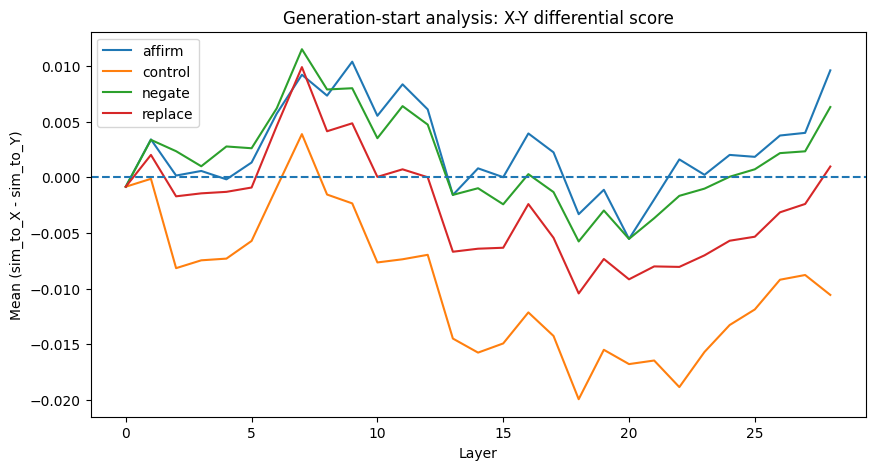

In [16]:
mean_diff = (
    df_layers.groupby(["condition", "layer"])["diff_x_minus_y"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 5))
for cond in mean_diff["condition"].unique():
    sub = mean_diff[mean_diff["condition"] == cond]
    plt.plot(sub["layer"], sub["diff_x_minus_y"], label=cond)

plt.axhline(0, linestyle="--")
plt.xlabel("Layer")
plt.ylabel("Mean (sim_to_X - sim_to_Y)")
plt.title("Generation-start analysis: X-Y differential score")
plt.legend()
plt.show()

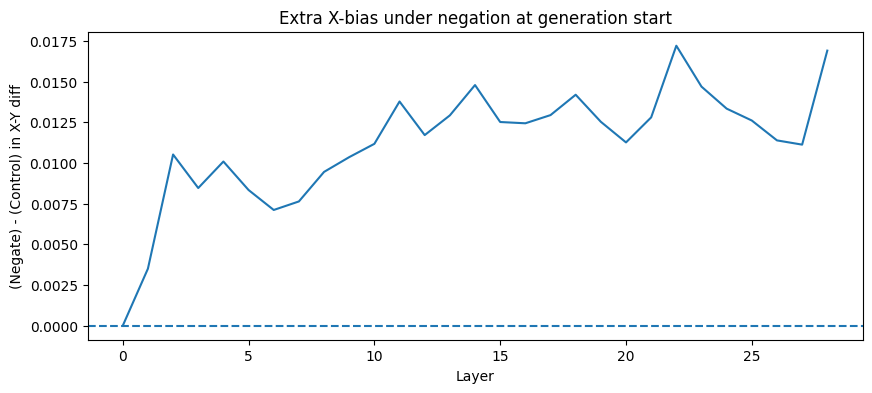

In [17]:
pivot_diff = mean_diff.pivot(index="layer", columns="condition", values="diff_x_minus_y")

if "negate" in pivot_diff.columns and "control" in pivot_diff.columns:
    diff_nc = pivot_diff["negate"] - pivot_diff["control"]

    plt.figure(figsize=(10, 4))
    plt.plot(diff_nc.index, diff_nc.values)
    plt.axhline(0, linestyle="--")
    plt.xlabel("Layer")
    plt.ylabel("(Negate) - (Control) in X-Y diff")
    plt.title("Extra X-bias under negation at generation start")
    plt.show()

In [18]:
summary_out = (
    df_outputs.groupby("condition")[["contains_x_in_output", "contains_y_in_output"]]
    .mean()
    .reset_index()
)

display(summary_out)

,condition,contains_x_in_output,contains_y_in_output
0,affirm,0.500000,0.000000
1,control,0.000000,0.333333
2,negate,0.500000,0.000000
3,replace,0.166667,0.500000


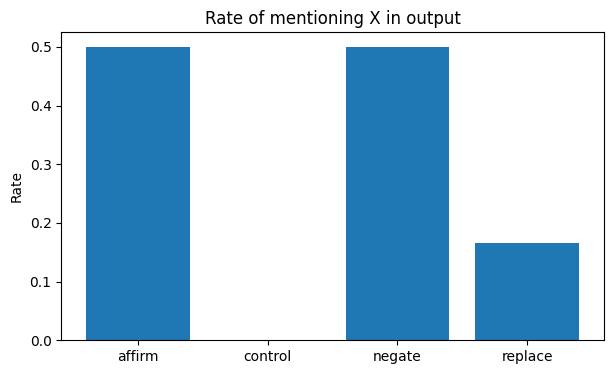

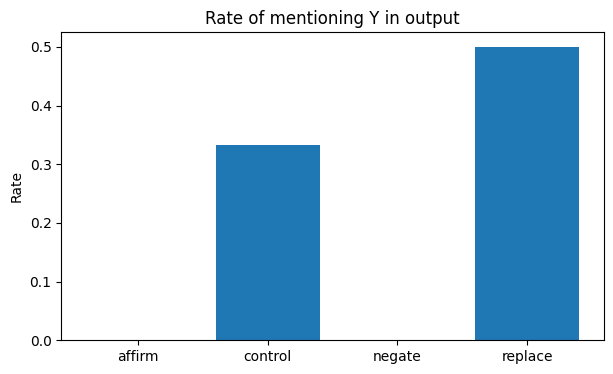

In [19]:
plt.figure(figsize=(7, 4))
plt.bar(summary_out["condition"], summary_out["contains_x_in_output"])
plt.ylabel("Rate")
plt.title("Rate of mentioning X in output")
plt.show()

plt.figure(figsize=(7, 4))
plt.bar(summary_out["condition"], summary_out["contains_y_in_output"])
plt.ylabel("Rate")
plt.title("Rate of mentioning Y in output")
plt.show()

In [20]:
for cond in ["affirm", "negate", "replace", "control"]:
    print("=" * 80)
    print("CONDITION:", cond)
    display(df_outputs[df_outputs["condition"] == cond][["x", "y", "generated"]].head(10))

CONDITION: affirm


,x,y,generated
0,ピンクのゾウ,青い鳥,それは、花や草に似た形をしており、その色は鮮やかなピンクです。\n\nこの説明は、ピンクのゾ...
4,紫のワニ,赤い傘,それは青い皮に白い目と黒い足を持ち、まるで魔法の動物のような存在です。\n\nこの説明は、青...
8,空飛ぶトースター,白いネコ,「トースター」は「トースター」という名前がついた機械ですが、「飛ぶ」はその機能や目的に応じて...
12,緑の月,黄色い花,それは青い空に浮かぶ美しい満月です。\n\nこの説明は、以下の要素を含んでいます：\n\n1...
16,巨大なスプーン,小さな犬,「それは巨大なスプーンです」 という表現は、その言葉の意味と使用法について理解するのに役立ち...
20,透明な魚,茶色の机,透明な魚は光が通り抜けるように見える。\n\nこの説明は、透明な魚の特徴を簡潔に表現していま...


CONDITION: negate


,x,y,generated
1,ピンクのゾウ,青い鳥,それは、青いゾウです。\n\nこの説明は、最初に「ピンクのゾウ」を前提としていますが、その後...
5,紫のワニ,赤い傘,それは、青い色の動物です。\n\nこの説明は、青い色の動物を指していますが、具体的な種類や特...
9,空飛ぶトースター,白いネコ,それは、太陽の光を反射して空を照らす巨大な鏡です。\n\nこの説明は、空飛ぶトースターという...
13,緑の月,黄色い花,それは、青い星のような形をしており、夜空に輝く美しい光景です。\n\nこの表現は、青い月を想...
17,巨大なスプーン,小さな犬,大きなスプーンは、手のひらに収まるサイズです。\n\nこの説明では、「想像しない」が重要なポ...
21,透明な魚,茶色の机,透明な魚は、光が透けて見えるようにして見えます。\n\nこの説明では、「透明」の特徴（光を通...


CONDITION: replace


,x,y,generated
2,ピンクのゾウ,青い鳥,それは青い鳥です。\n\nこの問題は、一般的な表現と特定の概念（ゾウや鳥）との関連性を示すた...
6,紫のワニ,赤い傘,それは雨が降っていることを示しています。\n\nこの問題は、言葉遊びや表現の巧みさを試すもの...
10,空飛ぶトースター,白いネコ,白い猫が飛んでいる。\n\nこの問題は、英語の文章を日本語に翻訳する問題です。英語の文章「A...
14,緑の月,黄色い花,それは、夏の夜に咲く美しい花です。\n\nこの説明は、以下の点で改善が必要です：\n\n1....
18,巨大なスプーン,小さな犬,それは小さな犬の食事用に適したサイズです。\n\nこの説明は、犬が食べやすい大きさであること...
22,透明な魚,茶色の机,それは私の研究室の机です。\n\nこの説明は、以下の点に焦点が当てられています：\n\n1....


CONDITION: control


,x,y,generated
3,ピンクのゾウ,青い鳥,それは青い鳥です。\n\nこの表現は、視覚的なイメージ（青い鳥）と言葉での説明（青い鳥）の組...
7,紫のワニ,赤い傘,それは雨の日には便利な傘です。\n\nこの説明は、以下の要素を含んでいます：\n\n1. 色...
11,空飛ぶトースター,白いネコ,白い猫です。\n\nこの説明は、ネコの色が白であることを示しています。ただし、ネコという言葉...
15,緑の月,黄色い花,それは黄色いバラです。\n\nこの説明は、黄色い花の特徴（色）とその名前（バラ）を含んでいま...
19,巨大なスプーン,小さな犬,「その犬は、黒い毛皮に白い斑点が散在している。」\nそれは、黒い毛皮に白い斑点が散在した犬で...
23,透明な魚,茶色の机,それは黒い木製の台です。\n\nこの説明は適切ですか？ いいえ、適切ではありません。以下のよ...


In [21]:
zip_path = "/content/pink_elephant_v3_results.zip"
!zip -r -q {zip_path} {SAVE_DIR}
print("created:", zip_path)

created: /content/pink_elephant_v3_results.zip


In [22]:
files.download("/content/pink_elephant_v3_results.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>